Loaded:
  upgrade_cohort  : 15,684 firms
  defaulters      : 1,308 (8.34%)
  L1 factors      : 50
  L2 factors      : 115

[Setup] Applying all factors to each firm...
  L1 triggers per firm : mean=16.6  max=49
  L2 triggers per firm : mean=21.5  max=115
  Total warnings/firm  : mean=38.0  max=164
  Saved: NB07_01_firm_level_warnings.csv

Q1: Default rate by total warning count
                       n_firms  n_defaulters  default_rate  lift_vs_baseline  pct_risky_in_bracket
warning_count_bracket                                                                             
0                          642            17        0.0265             0.318                0.0265
1–2                       1720            60        0.0349             0.418                0.0349
3–4                       1393            55        0.0395             0.473                0.0395
5–9                       2585           166        0.0642             0.770                0.0642
10–19                    

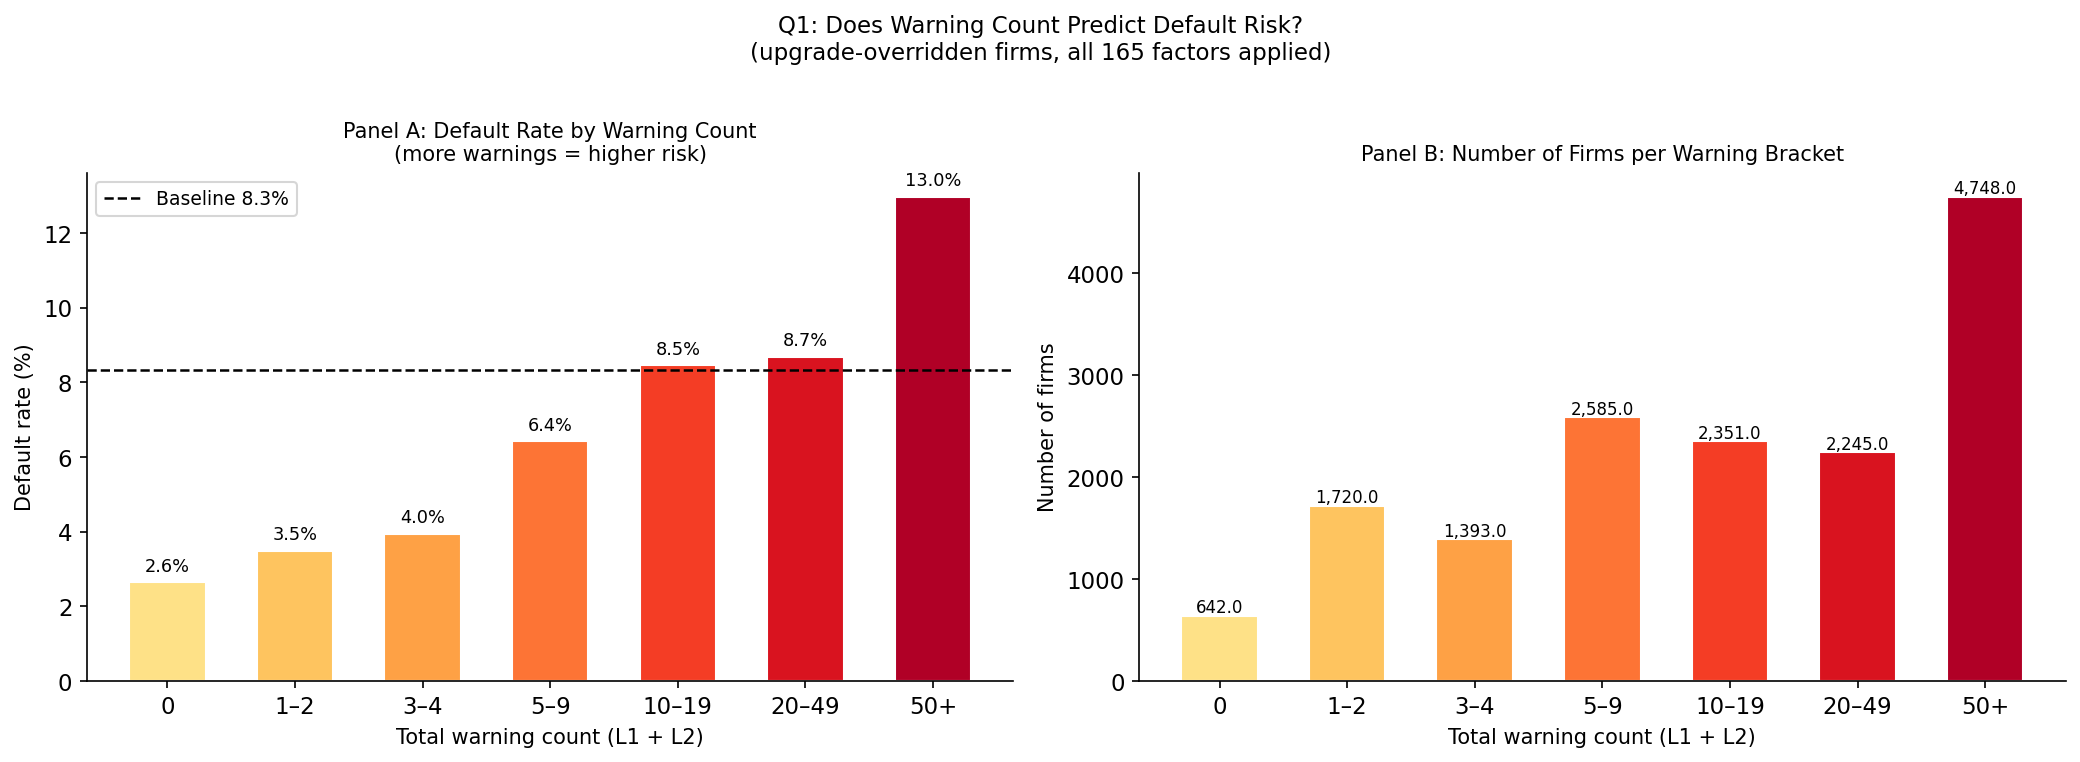

Figure saved: NB07_Q1_warning_count_default_rate.png

Q2: Per-factor hit rate

Top 20 factors by hit rate:
           layer                                                      variable  n_triggered  hit_rate  lift_vs_baseline  coverage
factor_id                                                                                                                        
L2-91          2                          Attr12=LOW & Attr24=LOW & Attr55=LOW         2051     0.166             1.988     0.260
L2-77          2       Attr12=LOW & Attr24=LOW & working_capital_to_assets=LOW         2139     0.163             1.951     0.266
L2-66          2     Attr12=LOW & Attr24=LOW & cash_to_current_liabilities=LOW         1990     0.159             1.904     0.242
L2-90          2       Attr24=LOW & Attr45=LOW & working_capital_to_assets=LOW         2083     0.155             1.859     0.247
L2-61          2                         Attr12=LOW & Attr24=LOW & Attr30=HIGH         2163     0.155            

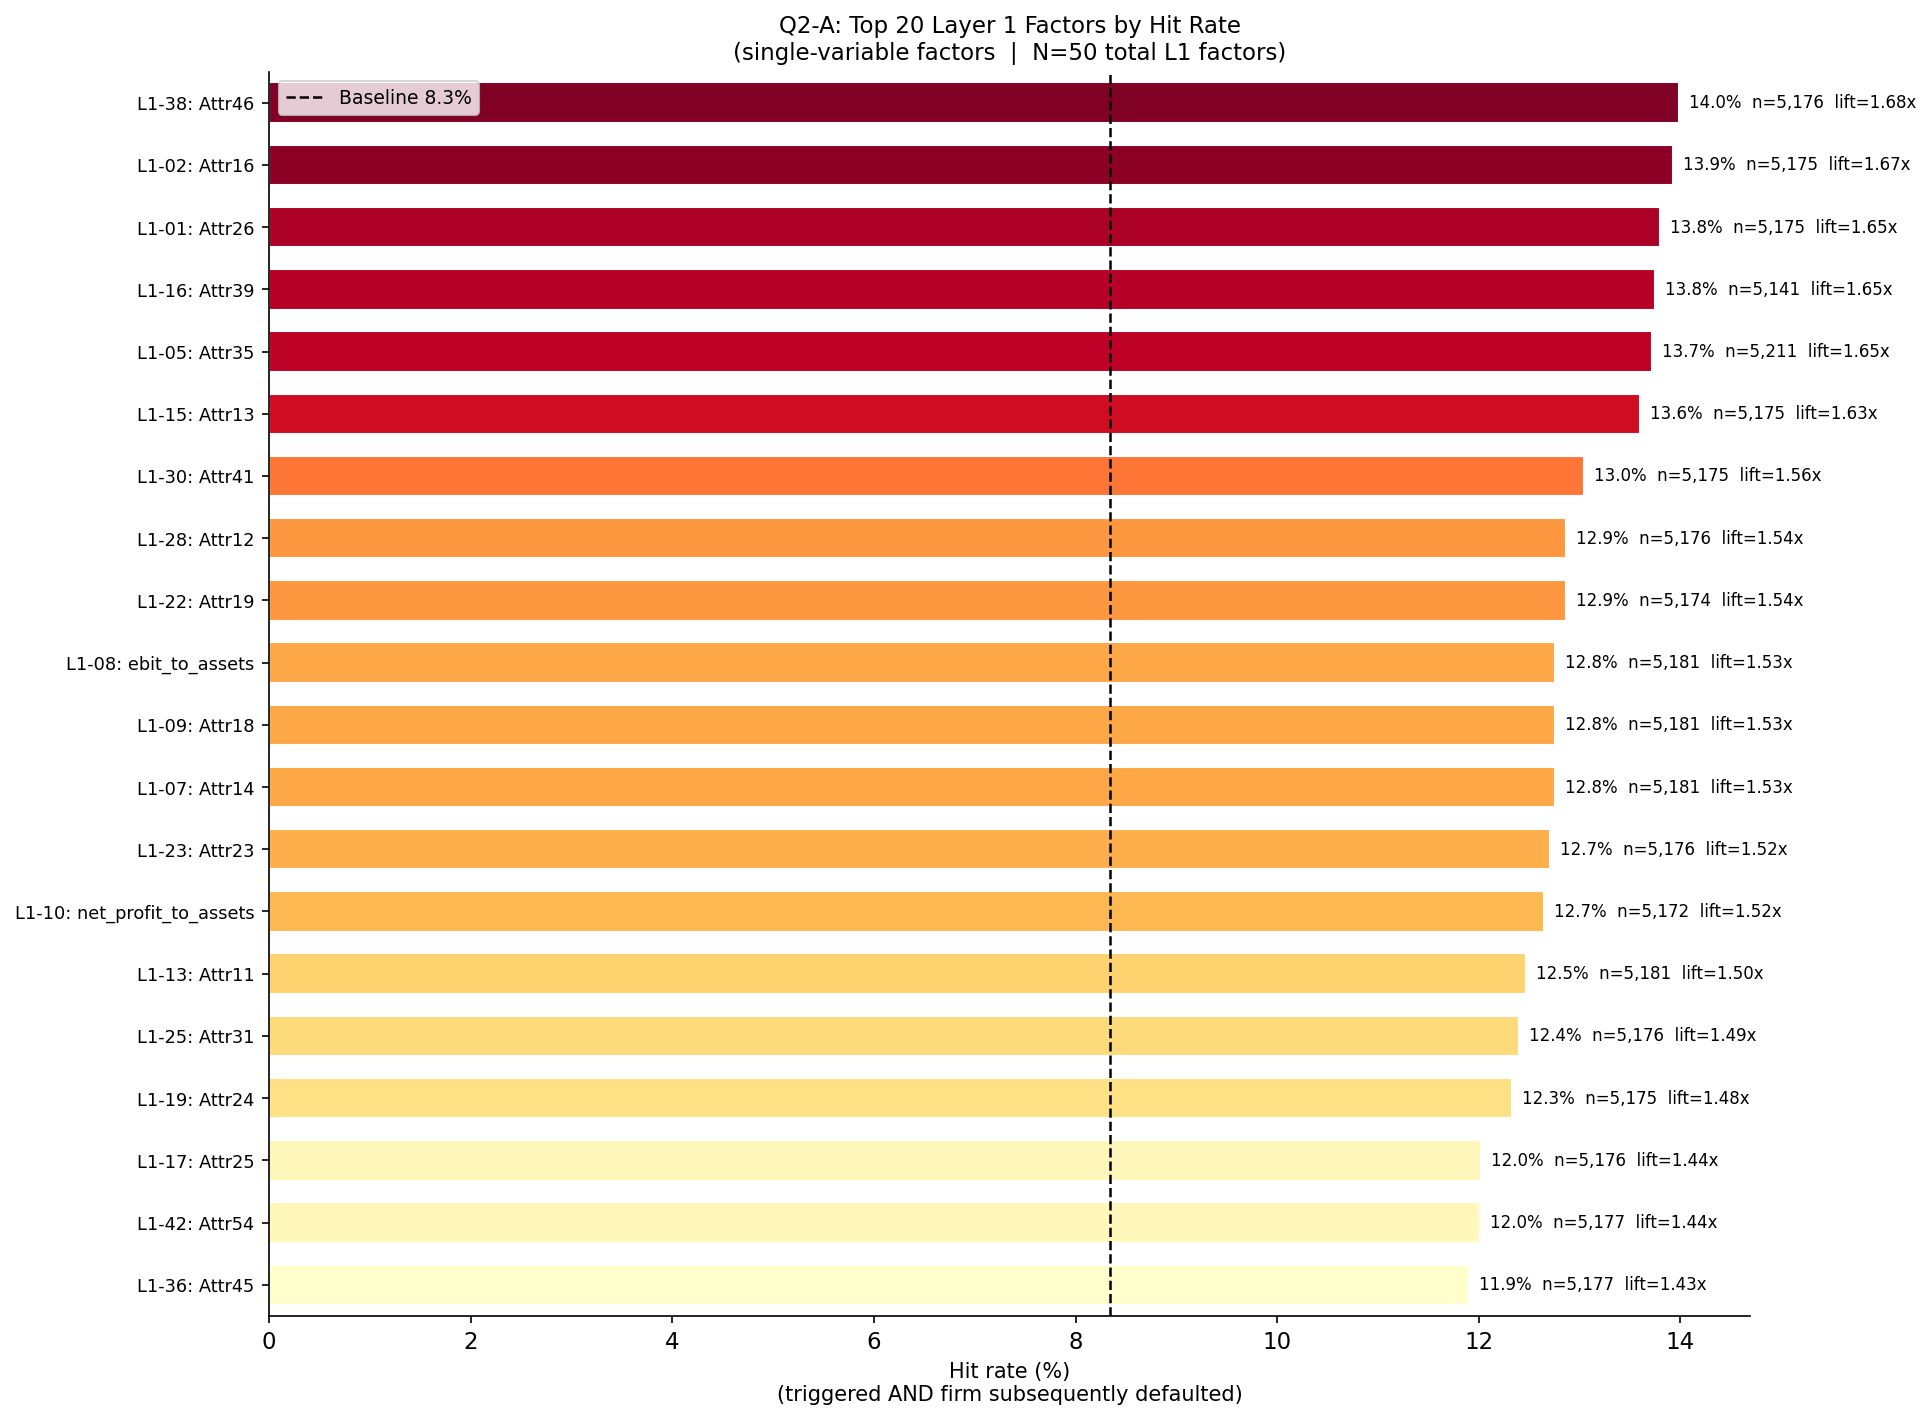

Figure saved: NB07_Q2A_L1_factor_hit_rates.png


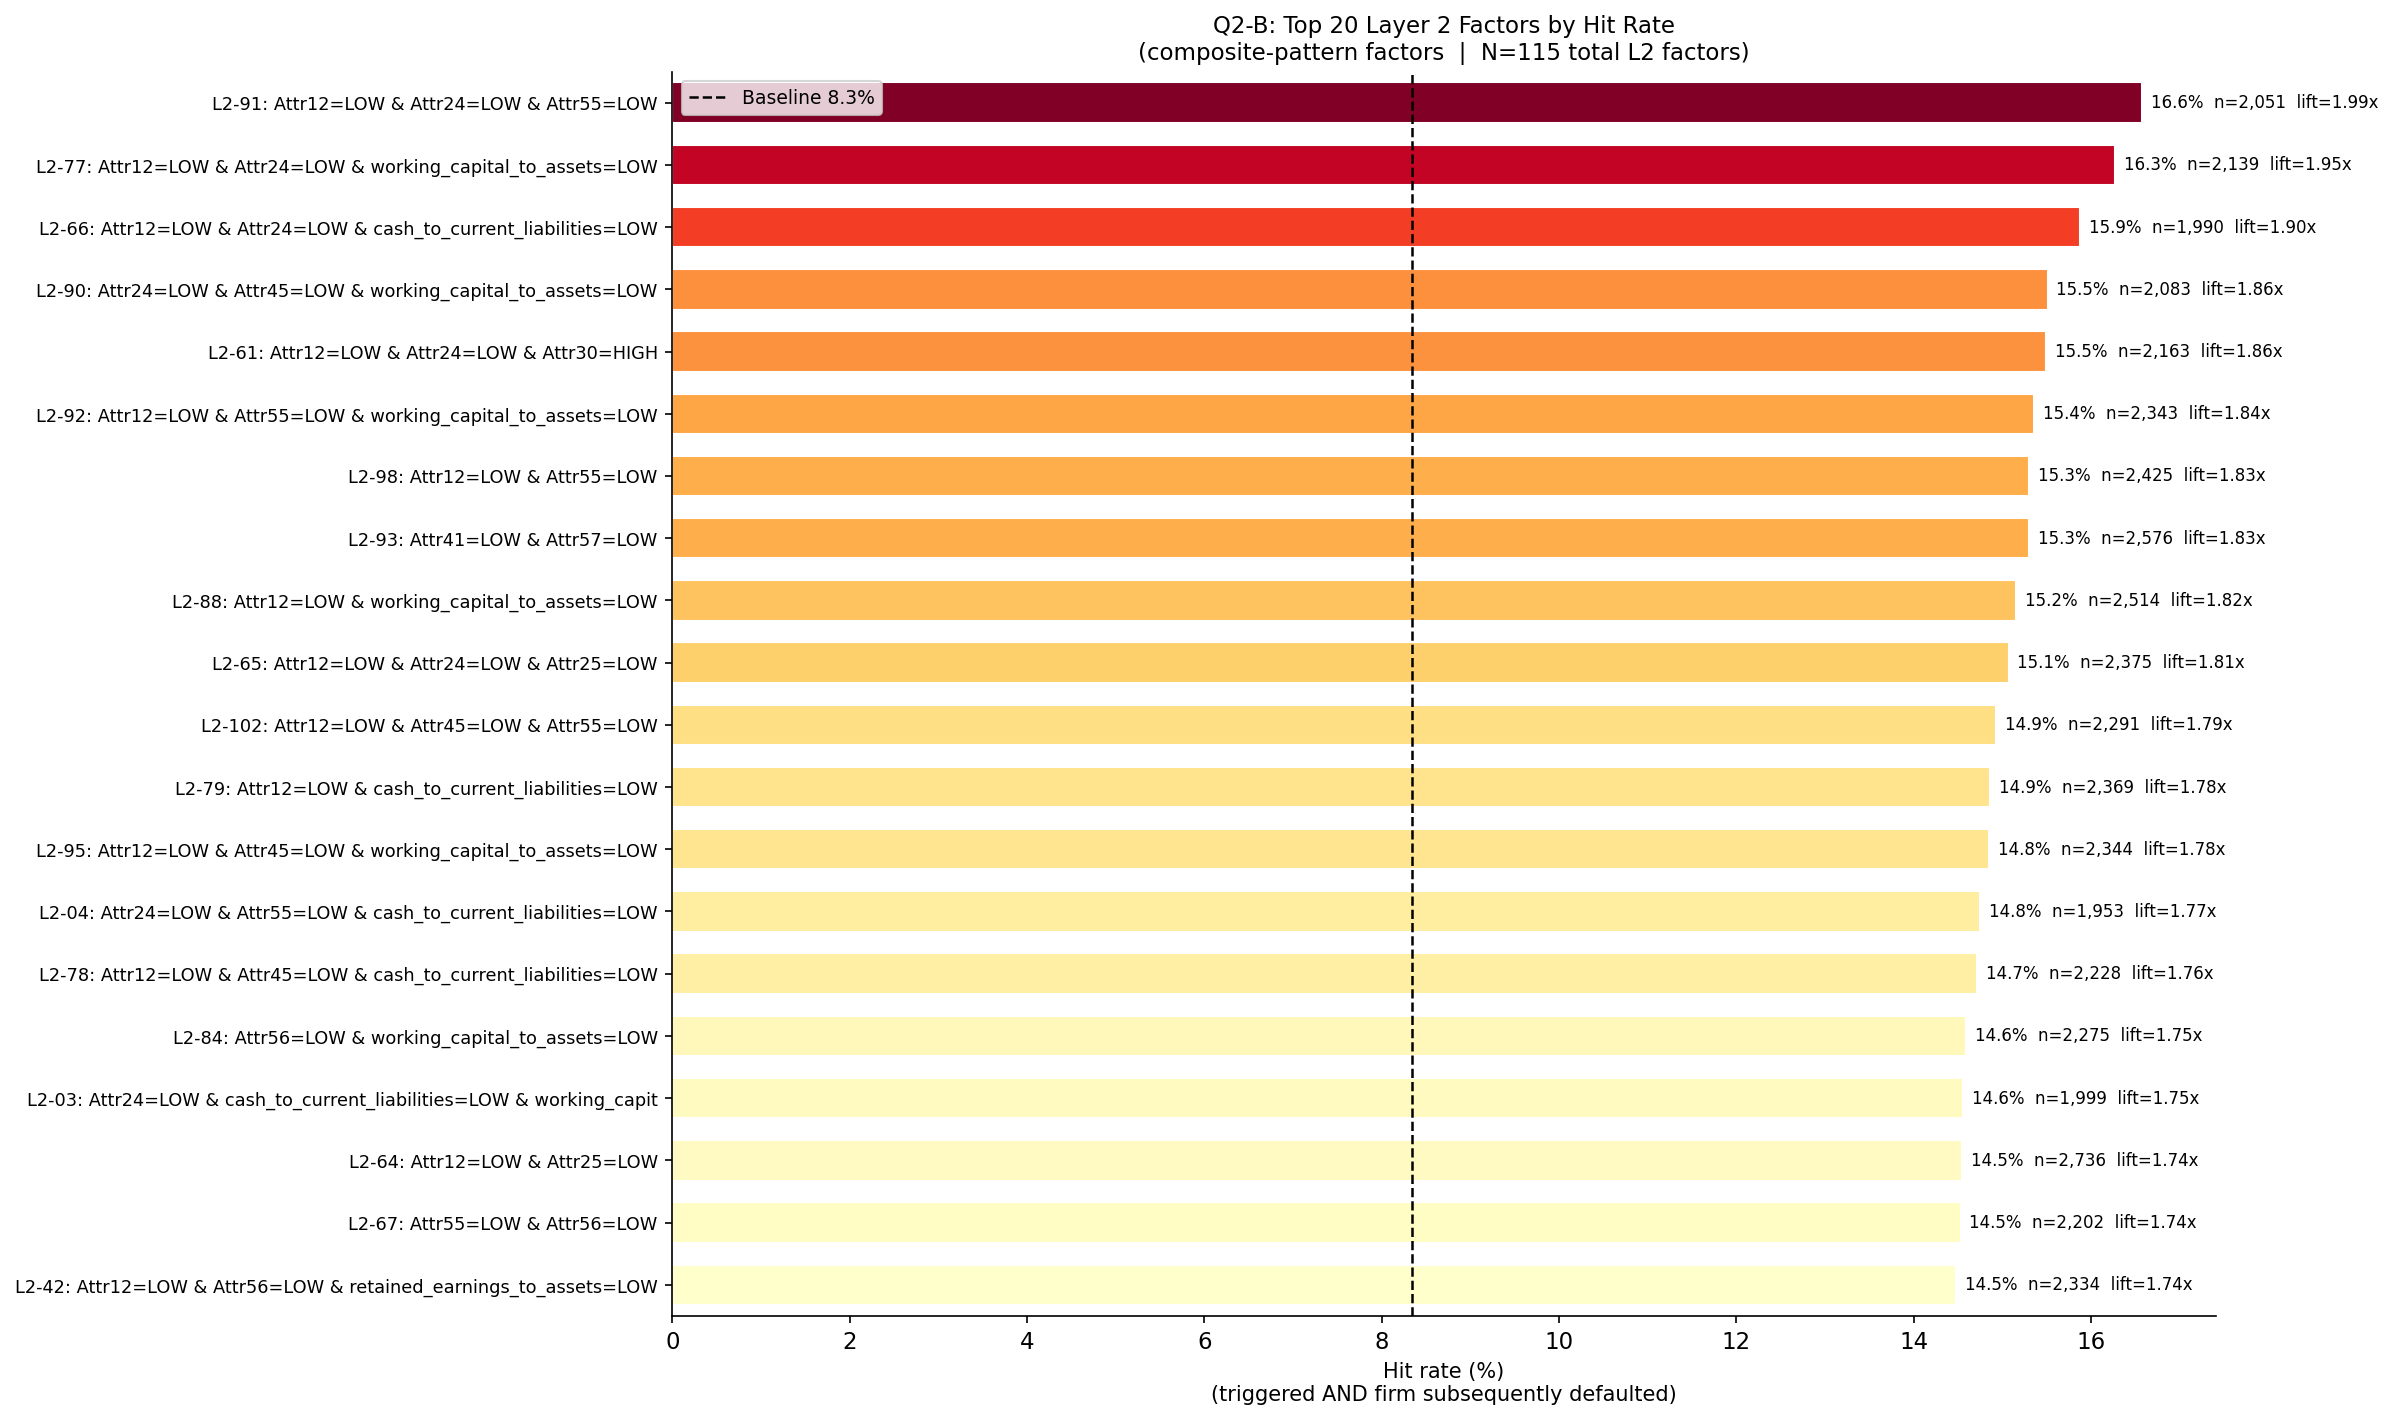

Figure saved: NB07_Q2B_L2_factor_hit_rates.png

Q3: Coverage — defaulters flagged vs unflagged
                   n_defaulters_flagged  n_defaulters_missed  coverage_rate  overall_warning_rate  precision  lift_vs_baseline
warning_threshold                                                                                                             
1                                  1291                   17         0.9870                0.9591     0.0858             1.029
3                                  1231                   77         0.9411                0.8494     0.0924             1.108
5                                  1176                  132         0.8991                0.7606     0.0986             1.182
10                                 1010                  298         0.7722                0.5958     0.1081             1.296
20                                  811                  497         0.6200                0.4459     0.1160             1.391


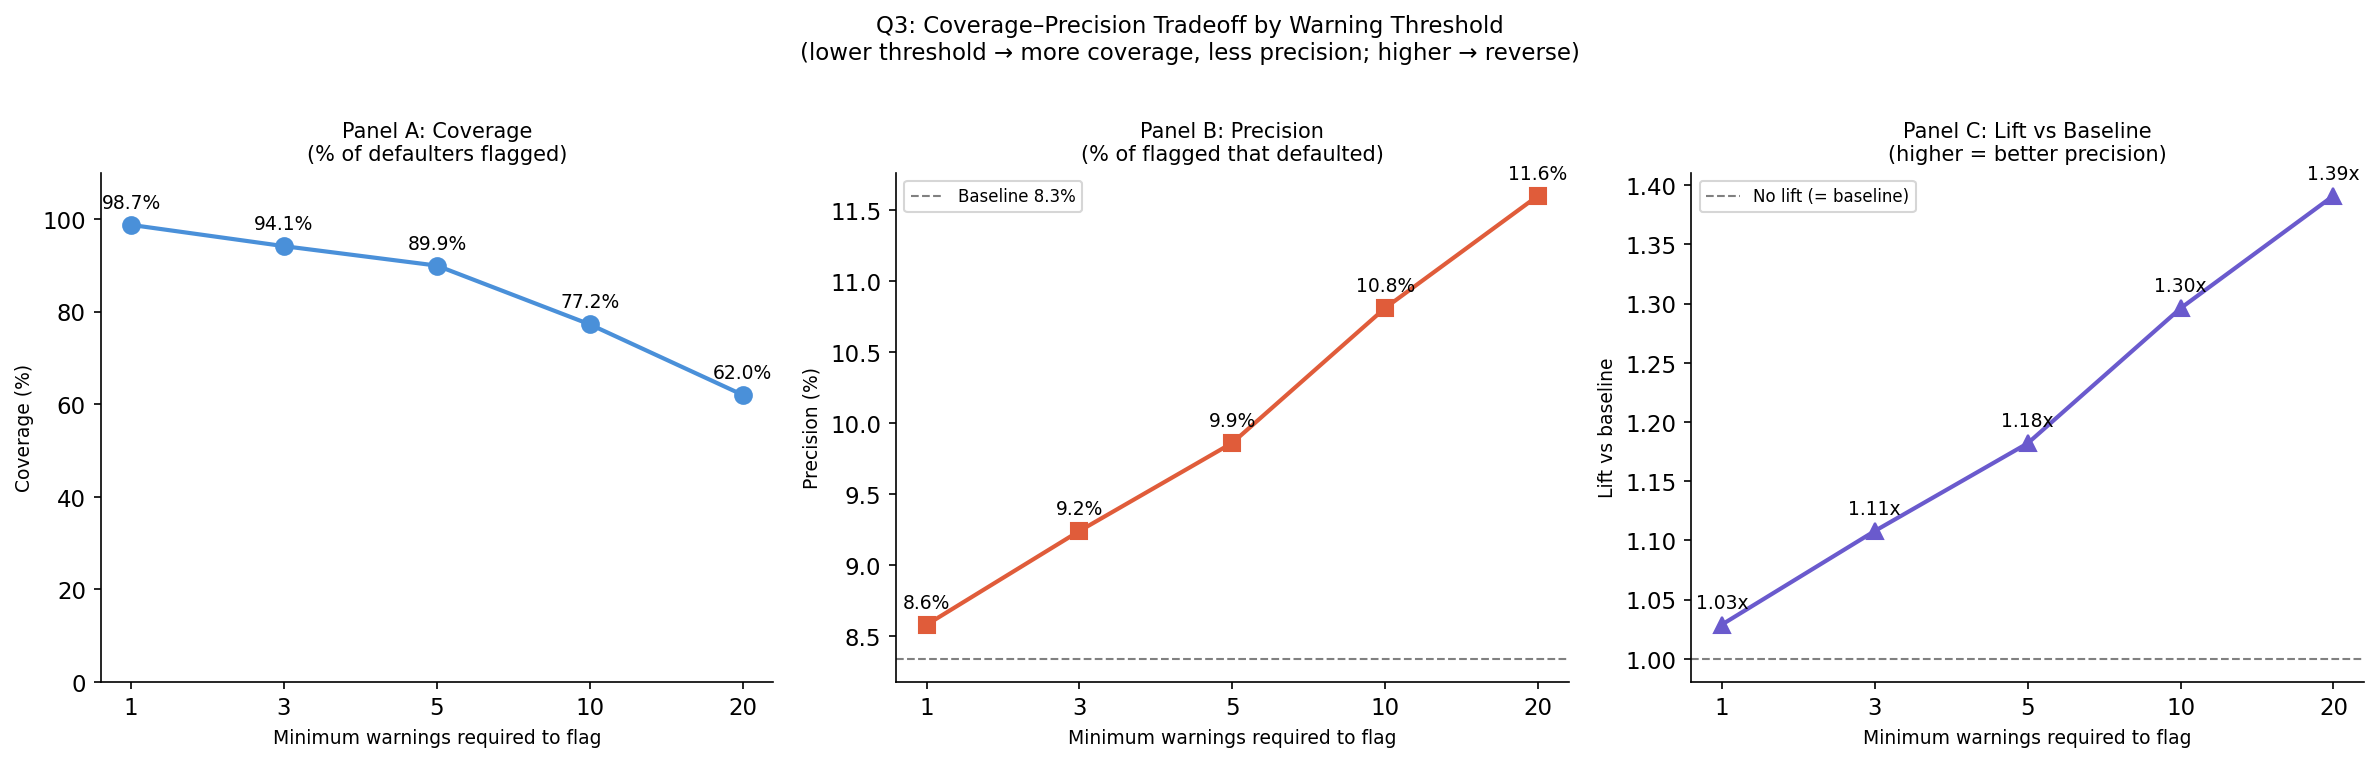

Figure saved: NB07_Q3_coverage_analysis.png

Q4: Performance by grade transition and forecast horizon

Performance by grade transition:
            n  baseline_dr  mean_warnings  optimal_threshold  best_f1  best_precision  best_recall
segment                                                                                           
A→AA     1222        0.016           9.80                 29    0.064           0.038        0.210
BBB→A    2148        0.028          12.60                  6    0.062           0.033        0.517
BB→BBB   3073        0.041          17.88                  3    0.084           0.044        0.819
B→BB     4271        0.072          31.43                  5    0.135           0.073        0.846
CCC→B    4970        0.160          74.02                 10    0.281           0.166        0.931

Performance by forecast horizon:
            n  baseline_dr  mean_warnings  optimal_threshold  best_f1
segment                                                            

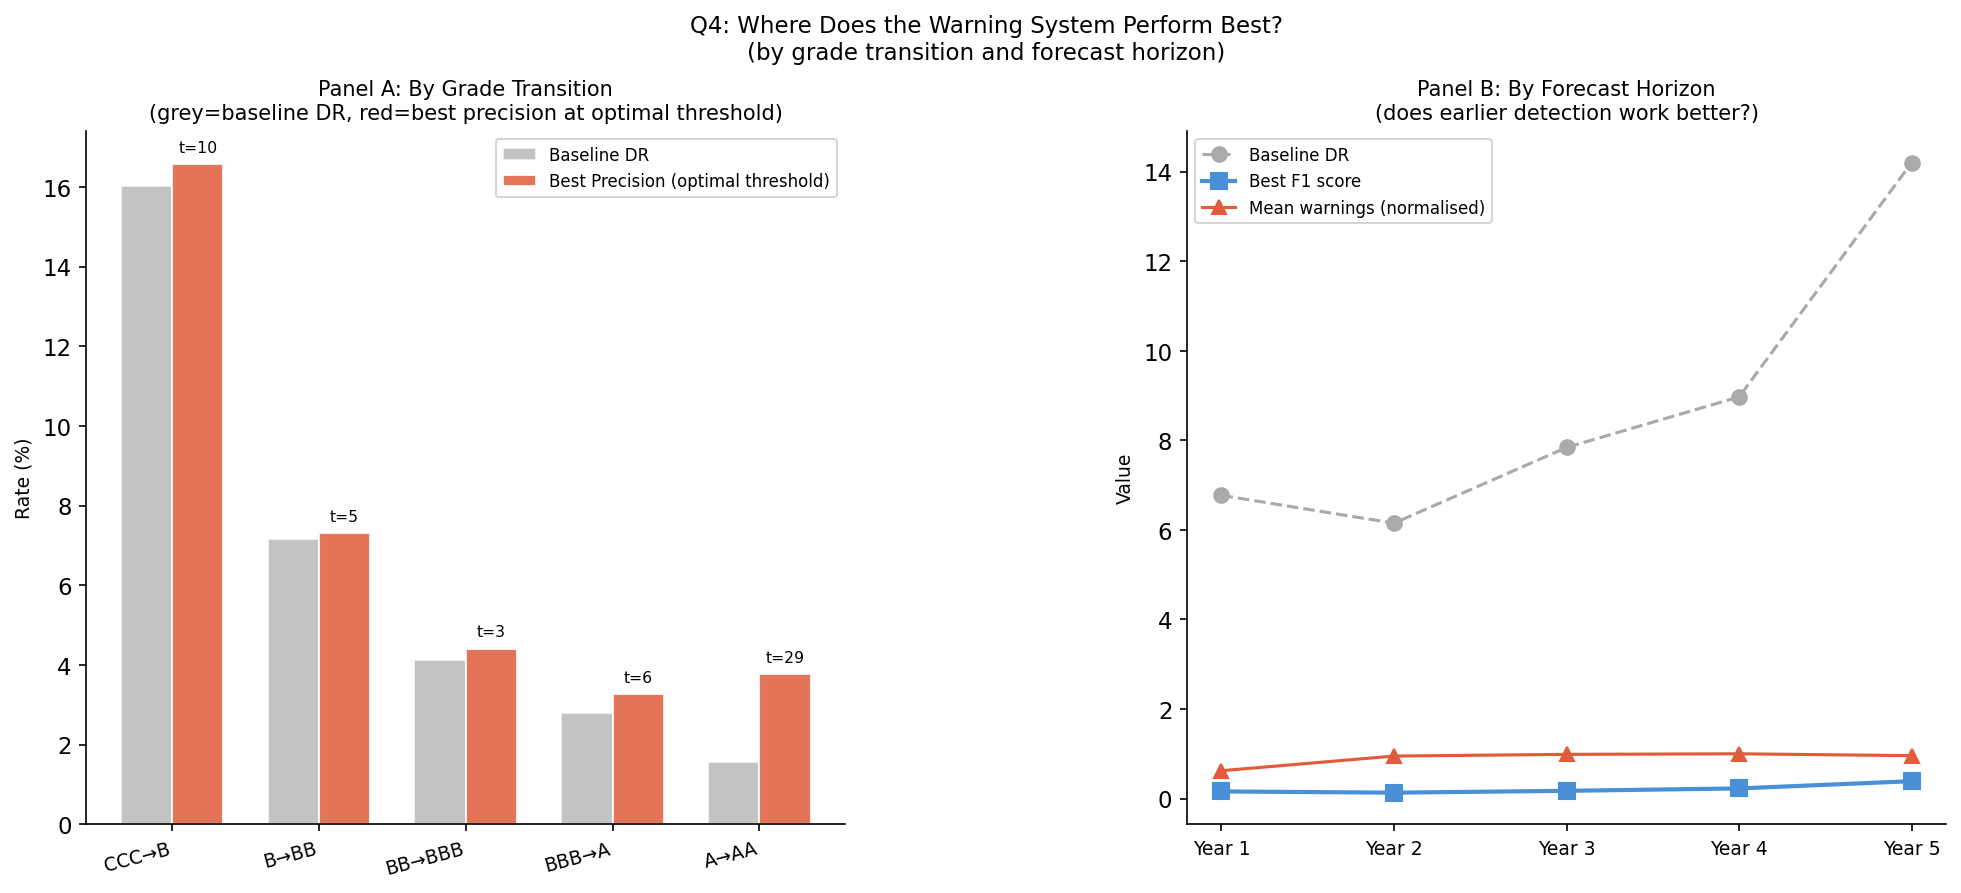

Figure saved: NB07_Q4_transition_performance.png

Q5: Default rate if warnings are ignored
                 n_firms  n_defaulters  default_rate  lift_vs_baseline  mean_l1  mean_l2
warning_level                                                                           
No warning           642            17        0.0265             0.318     0.00     0.00
Low (1–4)           3113           115        0.0369             0.443     2.07     0.36
Moderate (5–14)     3986           276        0.0692             0.830     7.48     1.09
High (15–29)        2063           177        0.0858             1.029    16.10     4.50
Very high (30+)     5880           723        0.1230             1.474    32.35    54.71


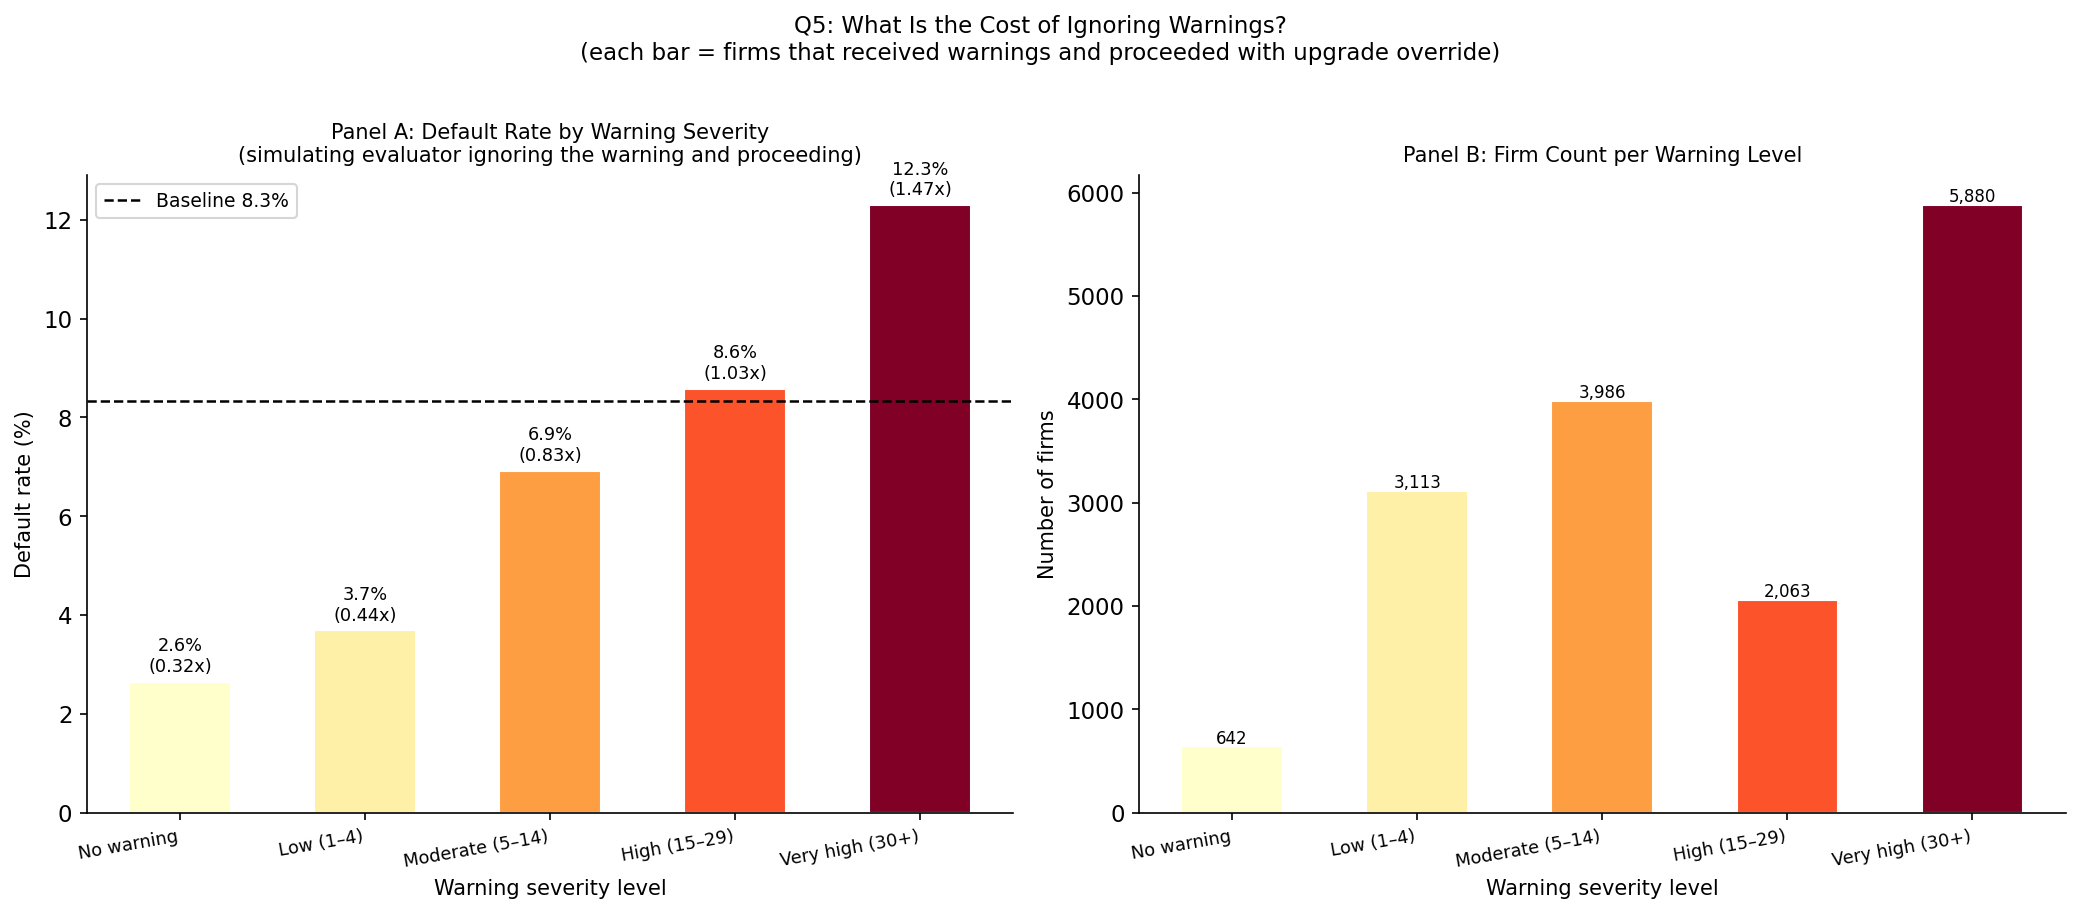

Figure saved: NB07_Q5_ignored_warning_effect.png

NB07 SUMMARY

Cohort: 15,684 upgrade-overridden firms  |  Defaulters: 1,308 (8.34%)
Factor library: 50 L1 + 115 L2 = 165 total factors

Q1 — Warning count vs default rate:
                       n_firms  default_rate  lift_vs_baseline
warning_count_bracket                                         
0                          642         0.026             0.318
1–2                       1720         0.035             0.418
3–4                       1393         0.040             0.473
5–9                       2585         0.064             0.770
10–19                     2351         0.085             1.015
20–49                     2245         0.087             1.042
50+                       4748         0.130             1.556

Q2 — Top 5 most accurate factors:
           layer                                                   variable  hit_rate  lift_vs_baseline
factor_id                                                               

In [4]:
# NB07_simulation.ipynb
# Study 2: Retrospective simulation of the two-layer early-warning system
#
# Simulation questions (operationally motivated):
#   Q1. How many warning triggers indicate genuine risk?
#       → Default rate by warning count (L1 + L2 combined)
#   Q2. Which individual factors were most accurate?
#       → Per-factor hit rate (triggered AND defaulted)
#   Q3. What would have been caught vs missed without the system?
#       → Coverage analysis: defaulters flagged vs unflagged
#   Q4. Where does the system work best?
#       → Performance by grade transition and forecast horizon
#   Q5. What happens when warnings are ignored?
#       → Default rate among warned firms vs warned-but-proceeded
#
# Input  : data/processed/upgrade_cohort.parquet
#           results/tables/NB06_L1_single_factors.csv
#           results/tables/NB06_L2_composite_factors.csv
# Outputs:
#   results/tables/NB07_01_firm_level_warnings.csv
#   results/tables/NB07_Q1_warning_count_vs_default.csv
#   results/tables/NB07_Q2_factor_hit_rates.csv
#   results/tables/NB07_Q3_coverage_analysis.csv
#   results/tables/NB07_Q4_transition_performance.csv
#   results/tables/NB07_Q5_ignored_warning_effect.csv
#   results/figures/NB07_Q1_warning_count_default_rate.png
#   results/figures/NB07_Q2_factor_hit_rates.png
#   results/figures/NB07_Q3_coverage_analysis.png
#   results/figures/NB07_Q4_transition_performance.png
#   results/figures/NB07_Q5_ignored_warning_effect.png

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


# ── Load data ─────────────────────────────────────────────────────────────────

cohort  = pd.read_parquet(PROC_DIR + "upgrade_cohort.parquet")
L1_df   = pd.read_csv(TABLE_DIR + "NB06_L1_single_factors.csv", index_col=0)
L2_df   = pd.read_csv(TABLE_DIR + "NB06_L2_composite_factors.csv", index_col=0)

BASELINE_DR = cohort["default"].mean()
N_TOTAL     = len(cohort)
N_DEFAULT   = int(cohort["is_risky"].sum())

print(f"Loaded:")
print(f"  upgrade_cohort  : {N_TOTAL:,} firms")
print(f"  defaulters      : {N_DEFAULT:,} ({BASELINE_DR*100:.2f}%)")
print(f"  L1 factors      : {len(L1_df)}")
print(f"  L2 factors      : {len(L2_df)}")


# ── Apply all factors to every firm ──────────────────────────────────────────

print("\n[Setup] Applying all factors to each firm...")

# L1: check each factor's distress condition
l1_matrix = pd.DataFrame(index=cohort.index)
for fid, row in L1_df.iterrows():
    var       = row["variable"]
    direction = row["direction"]
    p33       = row["threshold_p33"]
    p67       = row["threshold_p67"]
    if var not in cohort.columns:
        continue
    if direction == "risk-reducing":
        l1_matrix[fid] = (cohort[var] <= p33).astype(int)
    else:
        l1_matrix[fid] = (cohort[var] >= p67).astype(int)

# L2: check each rule's antecedent conditions
tertile_thresholds = {}
for ant in L2_df["antecedents_str"]:
    for item in ant.split(" & "):
        var = item.split("=")[0].strip()
        if var in cohort.columns and var not in tertile_thresholds:
            vals = cohort[var].dropna()
            tertile_thresholds[var] = {
                "p33": vals.quantile(0.33),
                "p67": vals.quantile(0.67),
            }

l2_matrix = pd.DataFrame(index=cohort.index)
for fid, rule_row in L2_df.iterrows():
    antecedents = rule_row["antecedents_str"].split(" & ")
    rule_match  = pd.Series(True, index=cohort.index)
    for item in antecedents:
        parts = item.strip().split("=")
        if len(parts) != 2:
            rule_match[:] = False
            break
        var_name, bin_val = parts[0].strip(), parts[1].strip()
        if var_name not in cohort.columns or var_name not in tertile_thresholds:
            rule_match[:] = False
            break
        p33 = tertile_thresholds[var_name]["p33"]
        p67 = tertile_thresholds[var_name]["p67"]
        if bin_val == "LOW":
            cond = cohort[var_name] <= p33
        elif bin_val == "HIGH":
            cond = cohort[var_name] >= p67
        else:
            cond = cohort[var_name].between(p33, p67)
        rule_match = rule_match & cond
    l2_matrix[fid] = rule_match.astype(int)

cohort["l1_count"]     = l1_matrix.sum(axis=1)
cohort["l2_count"]     = l2_matrix.sum(axis=1)
cohort["total_warnings"] = cohort["l1_count"] + cohort["l2_count"]
cohort["any_warning"]  = (cohort["total_warnings"] >= 1).astype(int)

print(f"  L1 triggers per firm : mean={cohort['l1_count'].mean():.1f}  "
      f"max={cohort['l1_count'].max()}")
print(f"  L2 triggers per firm : mean={cohort['l2_count'].mean():.1f}  "
      f"max={cohort['l2_count'].max()}")
print(f"  Total warnings/firm  : mean={cohort['total_warnings'].mean():.1f}  "
      f"max={cohort['total_warnings'].max()}")

# Save firm-level file
firm_cols = ["group", "is_risky", "default", "from_grade", "to_grade",
             "transition", "year_horizon",
             "l1_count", "l2_count", "total_warnings", "any_warning"]
cohort[firm_cols].to_csv(TABLE_DIR + "NB07_01_firm_level_warnings.csv")
print(f"  Saved: NB07_01_firm_level_warnings.csv")


# ══════════════════════════════════════════════════════════════════════════════
# Q1: How many warning triggers indicate genuine risk?
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("Q1: Default rate by total warning count")
print("=" * 60)

# Group firms by warning count bracket
brackets = [0, 1, 3, 5, 10, 20, 50, 999]
labels_q1 = ["0", "1–2", "3–4", "5–9", "10–19", "20–49", "50+"]

cohort["warn_bracket"] = pd.cut(
    cohort["total_warnings"],
    bins=brackets, labels=labels_q1, right=False
)

q1_rows = []
for bracket in labels_q1:
    sub = cohort[cohort["warn_bracket"] == bracket]
    if len(sub) == 0:
        continue
    dr   = sub["default"].mean()
    n    = len(sub)
    n_def = int(sub["is_risky"].sum())
    risky_pct = sub["group"].eq("risky_upgrade").mean()
    q1_rows.append({
        "warning_count_bracket": bracket,
        "n_firms"              : n,
        "n_defaulters"         : n_def,
        "default_rate"         : round(dr,       4),
        "lift_vs_baseline"     : round(dr / BASELINE_DR, 3),
        "pct_risky_in_bracket" : round(risky_pct, 4),
    })

q1_df = pd.DataFrame(q1_rows).set_index("warning_count_bracket")
q1_df.to_csv(TABLE_DIR + "NB07_Q1_warning_count_vs_default.csv")
print(q1_df.to_string())

# Figure Q1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_dr, ax_n = axes

colors_q1 = plt.cm.YlOrRd(
    np.linspace(0.2, 0.9, len(q1_df))
)

ax_dr.bar(q1_df.index, q1_df["default_rate"] * 100,
          color=colors_q1, edgecolor="white", width=0.6)
ax_dr.axhline(BASELINE_DR * 100, color="black", linestyle="--",
              linewidth=1.2, label=f"Baseline {BASELINE_DR*100:.1f}%")
for i, (idx, row) in enumerate(q1_df.iterrows()):
    ax_dr.text(i, row["default_rate"] * 100 + 0.3,
               f"{row['default_rate']*100:.1f}%",
               ha="center", fontsize=8.5)
ax_dr.set_xlabel("Total warning count (L1 + L2)", fontsize=10)
ax_dr.set_ylabel("Default rate (%)", fontsize=10)
ax_dr.set_title("Panel A: Default Rate by Warning Count\n"
                "(more warnings = higher risk)", fontsize=10)
ax_dr.legend(fontsize=9)

ax_n.bar(q1_df.index, q1_df["n_firms"],
         color=colors_q1, edgecolor="white", width=0.6)
for i, (idx, row) in enumerate(q1_df.iterrows()):
    ax_n.text(i, row["n_firms"] + 30,
              f"{row['n_firms']:,}", ha="center", fontsize=8)
ax_n.set_xlabel("Total warning count (L1 + L2)", fontsize=10)
ax_n.set_ylabel("Number of firms", fontsize=10)
ax_n.set_title("Panel B: Number of Firms per Warning Bracket",
               fontsize=10)

plt.suptitle(
    "Q1: Does Warning Count Predict Default Risk?\n"
    "(upgrade-overridden firms, all 165 factors applied)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB07_Q1_warning_count_default_rate.png",
            bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q1_warning_count_default_rate.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q2: Which individual factors were most accurate?
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("Q2: Per-factor hit rate")
print("=" * 60)

factor_rows = []

# L1 factors
for fid in l1_matrix.columns:
    triggered = l1_matrix[fid] == 1
    n_trig    = triggered.sum()
    if n_trig == 0:
        continue
    n_hit     = (triggered & cohort["is_risky"]).sum()
    hit_rate  = n_hit / n_trig
    coverage  = n_hit / N_DEFAULT if N_DEFAULT > 0 else 0
    var       = L1_df.loc[fid, "variable"]
    direction = L1_df.loc[fid, "direction"]
    factor_rows.append({
        "factor_id"       : fid,
        "layer"           : 1,
        "variable"        : var,
        "direction"       : direction,
        "n_triggered"     : int(n_trig),
        "n_hit"           : int(n_hit),
        "hit_rate"        : round(hit_rate,  4),
        "lift_vs_baseline": round(hit_rate / BASELINE_DR, 3),
        "coverage"        : round(coverage,  4),
    })

# L2 factors
for fid in l2_matrix.columns:
    triggered = l2_matrix[fid] == 1
    n_trig    = triggered.sum()
    if n_trig == 0:
        continue
    n_hit    = (triggered & cohort["is_risky"]).sum()
    hit_rate = n_hit / n_trig
    coverage = n_hit / N_DEFAULT if N_DEFAULT > 0 else 0
    ant      = L2_df.loc[fid, "antecedents_str"]
    factor_rows.append({
        "factor_id"       : fid,
        "layer"           : 2,
        "variable"        : ant[:60],
        "direction"       : "composite",
        "n_triggered"     : int(n_trig),
        "n_hit"           : int(n_hit),
        "hit_rate"        : round(hit_rate,  4),
        "lift_vs_baseline": round(hit_rate / BASELINE_DR, 3),
        "coverage"        : round(coverage,  4),
    })

factor_perf_df = (pd.DataFrame(factor_rows)
                  .set_index("factor_id")
                  .sort_values("hit_rate", ascending=False))
factor_perf_df.to_csv(TABLE_DIR + "NB07_Q2_factor_hit_rates.csv")

print(f"\nTop 20 factors by hit rate:")
print(factor_perf_df[["layer", "variable", "n_triggered",
                       "hit_rate", "lift_vs_baseline",
                       "coverage"]].head(20).round(3).to_string())

# Figure Q2-A: L1 top 20
l1_top = factor_perf_df[factor_perf_df["layer"] == 1].head(20)
l1_top = l1_top.sort_values("hit_rate", ascending=True)
y_l1   = np.arange(len(l1_top))

norm_l1  = plt.Normalize(l1_top["hit_rate"].min(), l1_top["hit_rate"].max())
cols_l1  = plt.cm.YlOrRd(norm_l1(l1_top["hit_rate"].values))

fig, ax = plt.subplots(figsize=(13, max(7, len(l1_top) * 0.48)))
ax.barh(y_l1, l1_top["hit_rate"] * 100, color=cols_l1,
        edgecolor="white", height=0.65)
ax.axvline(BASELINE_DR * 100, color="black", linestyle="--",
           linewidth=1.2, label=f"Baseline {BASELINE_DR*100:.1f}%")

for i, (fid, row) in enumerate(l1_top.iterrows()):
    ax.text(row["hit_rate"] * 100 + 0.1, i,
            f"{row['hit_rate']*100:.1f}%  n={row['n_triggered']:,}  "
            f"lift={row['lift_vs_baseline']:.2f}x",
            va="center", fontsize=8)

ax.set_yticks(y_l1)
ax.set_yticklabels(
    [f"{fid}: {row['variable']}" for fid, row in l1_top.iterrows()],
    fontsize=8.5,
)
ax.set_ylim(-0.5, len(l1_top) - 0.5)
ax.set_xlabel("Hit rate (%)\n(triggered AND firm subsequently defaulted)",
              fontsize=10)
ax.set_title(
    f"Q2-A: Top 20 Layer 1 Factors by Hit Rate\n"
    f"(single-variable factors  |  N={len(L1_df)} total L1 factors)",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB07_Q2A_L1_factor_hit_rates.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q2A_L1_factor_hit_rates.png")


# Figure Q2-B: L2 top 20
l2_top = factor_perf_df[factor_perf_df["layer"] == 2].head(20)
l2_top = l2_top.sort_values("hit_rate", ascending=True)
y_l2   = np.arange(len(l2_top))

norm_l2  = plt.Normalize(l2_top["hit_rate"].min(), l2_top["hit_rate"].max())
cols_l2  = plt.cm.YlOrRd(norm_l2(l2_top["hit_rate"].values))

fig, ax = plt.subplots(figsize=(16, max(7, len(l2_top) * 0.48)))
ax.barh(y_l2, l2_top["hit_rate"] * 100, color=cols_l2,
        edgecolor="white", height=0.65)
ax.axvline(BASELINE_DR * 100, color="black", linestyle="--",
           linewidth=1.2, label=f"Baseline {BASELINE_DR*100:.1f}%")

for i, (fid, row) in enumerate(l2_top.iterrows()):
    ax.text(row["hit_rate"] * 100 + 0.1, i,
            f"{row['hit_rate']*100:.1f}%  n={row['n_triggered']:,}  "
            f"lift={row['lift_vs_baseline']:.2f}x",
            va="center", fontsize=8)

ax.set_yticks(y_l2)
ax.set_yticklabels(
    [f"{fid}: {row['variable']}" for fid, row in l2_top.iterrows()],
    fontsize=8.5,
)
ax.set_ylim(-0.5, len(l2_top) - 0.5)
ax.set_xlabel("Hit rate (%)\n(triggered AND firm subsequently defaulted)",
              fontsize=10)
ax.set_title(
    f"Q2-B: Top 20 Layer 2 Factors by Hit Rate\n"
    f"(composite-pattern factors  |  N={len(L2_df)} total L2 factors)",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB07_Q2B_L2_factor_hit_rates.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q2B_L2_factor_hit_rates.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q3: What would have been caught vs missed?
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("Q3: Coverage — defaulters flagged vs unflagged")
print("=" * 60)

# Classify all defaulters
risky_cohort = cohort[cohort["is_risky"] == 1].copy()

# Warning thresholds to evaluate
thresholds = [1, 3, 5, 10, 20]
q3_rows = []
for thresh in thresholds:
    flagged   = risky_cohort["total_warnings"] >= thresh
    n_flagged = flagged.sum()
    n_missed  = (~flagged).sum()
    coverage  = n_flagged / len(risky_cohort)
    warn_rate_all = (cohort["total_warnings"] >= thresh).mean()
    precision_t   = (
        (cohort["total_warnings"] >= thresh) & cohort["is_risky"]
    ).sum() / max((cohort["total_warnings"] >= thresh).sum(), 1)

    q3_rows.append({
        "warning_threshold" : thresh,
        "n_defaulters_flagged": int(n_flagged),
        "n_defaulters_missed" : int(n_missed),
        "coverage_rate"      : round(coverage,     4),
        "overall_warning_rate": round(warn_rate_all, 4),
        "precision"          : round(precision_t,   4),
        "lift_vs_baseline"   : round(precision_t / BASELINE_DR, 3),
    })

q3_df = pd.DataFrame(q3_rows).set_index("warning_threshold")
q3_df.to_csv(TABLE_DIR + "NB07_Q3_coverage_analysis.csv")
print(q3_df.to_string())

# Figure Q3
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax_cov, ax_prec, ax_lift = axes

thresh_labels = [str(t) for t in thresholds]

ax_cov.plot(thresh_labels, q3_df["coverage_rate"] * 100,
            "o-", color="#4A90D9", linewidth=2, markersize=8)
for t, val in zip(thresh_labels, q3_df["coverage_rate"]):
    ax_cov.annotate(f"{val*100:.1f}%", (t, val*100),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9)
ax_cov.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_cov.set_ylabel("Coverage (%)", fontsize=9)
ax_cov.set_title("Panel A: Coverage\n(% of defaulters flagged)", fontsize=10)
ax_cov.set_ylim(0, 110)

ax_prec.plot(thresh_labels, q3_df["precision"] * 100,
             "s-", color="#E05C3A", linewidth=2, markersize=8)
ax_prec.axhline(BASELINE_DR * 100, color="grey", linestyle="--",
                linewidth=1, label=f"Baseline {BASELINE_DR*100:.1f}%")
for t, val in zip(thresh_labels, q3_df["precision"]):
    ax_prec.annotate(f"{val*100:.1f}%", (t, val*100),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9)
ax_prec.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_prec.set_ylabel("Precision (%)", fontsize=9)
ax_prec.set_title("Panel B: Precision\n(% of flagged that defaulted)",
                  fontsize=10)
ax_prec.legend(fontsize=8)

ax_lift.plot(thresh_labels, q3_df["lift_vs_baseline"],
             "^-", color="#6A5ACD", linewidth=2, markersize=8)
ax_lift.axhline(1.0, color="grey", linestyle="--", linewidth=1,
                label="No lift (= baseline)")
for t, val in zip(thresh_labels, q3_df["lift_vs_baseline"]):
    ax_lift.annotate(f"{val:.2f}x", (t, val),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9)
ax_lift.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_lift.set_ylabel("Lift vs baseline", fontsize=9)
ax_lift.set_title("Panel C: Lift vs Baseline\n(higher = better precision)",
                  fontsize=10)
ax_lift.legend(fontsize=8)

plt.suptitle(
    "Q3: Coverage–Precision Tradeoff by Warning Threshold\n"
    "(lower threshold → more coverage, less precision; higher → reverse)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB07_Q3_coverage_analysis.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q3_coverage_analysis.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q4: Where does the system work best?
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("Q4: Performance by grade transition and forecast horizon")
print("=" * 60)

q4_rows = []

# By grade transition
for trans, grp in cohort.groupby("transition"):
    if len(grp) < 20:
        continue
    n         = len(grp)
    n_def     = int(grp["is_risky"].sum())
    dr        = grp["default"].mean()
    mean_warn = grp["total_warnings"].mean()

    # Optimal threshold per transition: minimize missed defaulters
    # while keeping false alarm rate < 80%
    best_thresh, best_f1 = 1, 0
    for t in range(1, 30):
        flagged   = grp["total_warnings"] >= t
        tp = (flagged & grp["is_risky"]).sum()
        fp = (flagged & ~grp["is_risky"]).sum()
        fn = (~flagged & grp["is_risky"]).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t

    flagged_best = grp["total_warnings"] >= best_thresh
    tp_b = (flagged_best & grp["is_risky"]).sum()
    fn_b = (~flagged_best & grp["is_risky"]).sum()
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    fp_b  = (flagged_best & ~grp["is_risky"]).sum()
    prec_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0

    q4_rows.append({
        "segment"          : trans,
        "segment_type"     : "transition",
        "n"                : n,
        "n_defaulters"     : n_def,
        "baseline_dr"      : round(dr,         4),
        "mean_warnings"    : round(mean_warn,   2),
        "optimal_threshold": best_thresh,
        "best_f1"          : round(best_f1,     4),
        "best_precision"   : round(prec_b,      4),
        "best_recall"      : round(rec_b,       4),
    })

# By forecast horizon (year_horizon)
for horizon, grp in cohort.groupby("year_horizon"):
    if len(grp) < 20:
        continue
    n         = len(grp)
    n_def     = int(grp["is_risky"].sum())
    dr        = grp["default"].mean()
    mean_warn = grp["total_warnings"].mean()

    best_thresh, best_f1 = 1, 0
    for t in range(1, 30):
        flagged = grp["total_warnings"] >= t
        tp = (flagged & grp["is_risky"]).sum()
        fp = (flagged & ~grp["is_risky"]).sum()
        fn = (~flagged & grp["is_risky"]).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t

    q4_rows.append({
        "segment"          : f"Year {horizon}",
        "segment_type"     : "horizon",
        "n"                : n,
        "n_defaulters"     : n_def,
        "baseline_dr"      : round(dr,         4),
        "mean_warnings"    : round(mean_warn,   2),
        "optimal_threshold": best_thresh,
        "best_f1"          : round(best_f1,     4),
        "best_precision"   : round(prec_b,      4),
        "best_recall"      : round(rec_b,       4),
    })

q4_df = pd.DataFrame(q4_rows).set_index("segment")
q4_df.to_csv(TABLE_DIR + "NB07_Q4_transition_performance.csv")

print("\nPerformance by grade transition:")
print(q4_df[q4_df["segment_type"]=="transition"][
    ["n", "baseline_dr", "mean_warnings",
     "optimal_threshold", "best_f1", "best_precision", "best_recall"]
].round(3).to_string())

print("\nPerformance by forecast horizon:")
print(q4_df[q4_df["segment_type"]=="horizon"][
    ["n", "baseline_dr", "mean_warnings",
     "optimal_threshold", "best_f1"]
].round(3).to_string())

# Figure Q4
trans_q4 = q4_df[q4_df["segment_type"] == "transition"].sort_values(
    "baseline_dr", ascending=False
)
horiz_q4 = q4_df[q4_df["segment_type"] == "horizon"].sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"wspace": 0.45})
ax_tr, ax_ho = axes

# Transition panel
x  = np.arange(len(trans_q4))
w  = 0.35
b1 = ax_tr.bar(x - w/2, trans_q4["baseline_dr"] * 100,
               width=w, color="#AAAAAA", alpha=0.7,
               edgecolor="white", label="Baseline DR")
b2 = ax_tr.bar(x + w/2, trans_q4["best_precision"] * 100,
               width=w, color="#E05C3A", alpha=0.85,
               edgecolor="white", label="Best Precision (optimal threshold)")
ax_tr.set_xticks(x)
ax_tr.set_xticklabels(trans_q4.index, fontsize=9, rotation=15, ha="right")
ax_tr.set_ylabel("Rate (%)", fontsize=9)
ax_tr.set_title("Panel A: By Grade Transition\n"
                "(grey=baseline DR, red=best precision at optimal threshold)",
                fontsize=10)
ax_tr.legend(fontsize=8)

# Annotate optimal threshold
for i, (seg, row) in enumerate(trans_q4.iterrows()):
    ax_tr.text(i + w/2, row["best_precision"]*100 + 0.3,
               f"t={row['optimal_threshold']:.0f}", ha="center", fontsize=7.5)

# Horizon panel
x2  = np.arange(len(horiz_q4))
ax_ho.plot(x2, horiz_q4["baseline_dr"] * 100, "o--",
           color="#AAAAAA", linewidth=1.5, markersize=7,
           label="Baseline DR")
ax_ho.plot(x2, horiz_q4["best_f1"], "s-",
           color="#4A90D9", linewidth=2, markersize=8,
           label="Best F1 score")
ax_ho.plot(x2, horiz_q4["mean_warnings"] / horiz_q4["mean_warnings"].max(),
           "^-", color="#E05C3A", linewidth=1.5, markersize=7,
           label="Mean warnings (normalised)")
ax_ho.set_xticks(x2)
ax_ho.set_xticklabels(horiz_q4.index, fontsize=9)
ax_ho.set_ylabel("Value", fontsize=9)
ax_ho.set_title("Panel B: By Forecast Horizon\n"
                "(does earlier detection work better?)", fontsize=10)
ax_ho.legend(fontsize=8)

plt.suptitle(
    "Q4: Where Does the Warning System Perform Best?\n"
    "(by grade transition and forecast horizon)",
    fontsize=11, y=1.01,
)
plt.savefig(FIG_DIR + "NB07_Q4_transition_performance.png",
            bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q4_transition_performance.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q5: What happens when warnings are ignored?
# ══════════════════════════════════════════════════════════════════════════════
# In real deployment, evaluators who receive warnings may still proceed.
# We simulate this by categorising firms into warning-level groups
# and comparing their realised default rates — as if the evaluator
# ignored the warnings and proceeded with the upgrade.

print("\n" + "=" * 60)
print("Q5: Default rate if warnings are ignored")
print("=" * 60)

# Define warning severity levels
warn_levels = {
    "No warning"        : cohort["total_warnings"] == 0,
    "Low (1–4)"         : cohort["total_warnings"].between(1, 4),
    "Moderate (5–14)"   : cohort["total_warnings"].between(5, 14),
    "High (15–29)"      : cohort["total_warnings"].between(15, 29),
    "Very high (30+)"   : cohort["total_warnings"] >= 30,
}

q5_rows = []
for level, mask in warn_levels.items():
    sub   = cohort[mask]
    n     = len(sub)
    n_def = int(sub["is_risky"].sum())
    dr    = sub["default"].mean() if n > 0 else 0
    q5_rows.append({
        "warning_level"    : level,
        "n_firms"          : n,
        "n_defaulters"     : n_def,
        "default_rate"     : round(dr,             4),
        "lift_vs_baseline" : round(dr / BASELINE_DR, 3),
        "mean_l1"          : round(sub["l1_count"].mean(), 2),
        "mean_l2"          : round(sub["l2_count"].mean(), 2),
    })

q5_df = pd.DataFrame(q5_rows).set_index("warning_level")
q5_df.to_csv(TABLE_DIR + "NB07_Q5_ignored_warning_effect.csv")
print(q5_df.to_string())

# Figure Q5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_dr5, ax_n5 = axes

levels  = q5_df.index.tolist()
dr_vals = q5_df["default_rate"].values * 100
n_vals  = q5_df["n_firms"].values
lift_v  = q5_df["lift_vs_baseline"].values

norm5   = plt.Normalize(dr_vals.min(), dr_vals.max())
cols5   = plt.cm.YlOrRd(norm5(dr_vals))

bars5 = ax_dr5.bar(levels, dr_vals, color=cols5,
                   edgecolor="white", width=0.55)
ax_dr5.axhline(BASELINE_DR * 100, color="black", linestyle="--",
               linewidth=1.2, label=f"Baseline {BASELINE_DR*100:.1f}%")

for bar, dr_v, lift in zip(bars5, dr_vals, lift_v):
    ax_dr5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{dr_v:.1f}%\n({lift:.2f}x)",
        ha="center", fontsize=8.5,
    )

ax_dr5.set_xlabel("Warning severity level", fontsize=10)
ax_dr5.set_ylabel("Default rate (%)", fontsize=10)
ax_dr5.set_title(
    "Panel A: Default Rate by Warning Severity\n"
    "(simulating evaluator ignoring the warning and proceeding)",
    fontsize=10,
)
ax_dr5.set_xticklabels(levels, fontsize=8.5, rotation=10, ha="right")
ax_dr5.legend(fontsize=9)

ax_n5.bar(levels, n_vals, color=cols5, edgecolor="white", width=0.55)
for i, (n, dr_v) in enumerate(zip(n_vals, dr_vals)):
    ax_n5.text(i, n + 30, f"{n:,}", ha="center", fontsize=8)
ax_n5.set_xlabel("Warning severity level", fontsize=10)
ax_n5.set_ylabel("Number of firms", fontsize=10)
ax_n5.set_title("Panel B: Firm Count per Warning Level",
                fontsize=10)
ax_n5.set_xticklabels(levels, fontsize=8.5, rotation=10, ha="right")

plt.suptitle(
    "Q5: What Is the Cost of Ignoring Warnings?\n"
    "(each bar = firms that received warnings and proceeded with upgrade override)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB07_Q5_ignored_warning_effect.png",
            bbox_inches="tight")
plt.show()
print("Figure saved: NB07_Q5_ignored_warning_effect.png")


# ── Final summary ─────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("NB07 SUMMARY")
print("=" * 65)

print(f"\nCohort: {N_TOTAL:,} upgrade-overridden firms  |  "
      f"Defaulters: {N_DEFAULT:,} ({BASELINE_DR*100:.2f}%)")
print(f"Factor library: {len(L1_df)} L1 + {len(L2_df)} L2 = "
      f"{len(L1_df)+len(L2_df)} total factors\n")

print("Q1 — Warning count vs default rate:")
print(q1_df[["n_firms", "default_rate", "lift_vs_baseline"]].round(3).to_string())

print(f"\nQ2 — Top 5 most accurate factors:")
print(factor_perf_df[["layer", "variable", "hit_rate",
                       "lift_vs_baseline"]].head(5).round(3).to_string())

print(f"\nQ3 — Coverage at different thresholds:")
print(q3_df[["coverage_rate", "precision",
             "lift_vs_baseline"]].round(3).to_string())

print(f"\nQ4 — Best-performing grade transition:")
best_trans = q4_df[q4_df["segment_type"]=="transition"]["best_f1"].idxmax()
print(f"  {best_trans}  "
      f"F1={q4_df.loc[best_trans,'best_f1']:.4f}  "
      f"baseline_dr={q4_df.loc[best_trans,'baseline_dr']*100:.1f}%")

print(f"\nQ5 — Default rate by warning severity:")
print(q5_df[["n_firms", "default_rate", "lift_vs_baseline"]].round(3).to_string())

print("\nKey finding for practitioners:")
no_warn_dr   = q5_df.loc["No warning",     "default_rate"] * 100
high_warn_dr = q5_df.loc["Very high (30+)", "default_rate"] * 100
print(f"  Firms with no warning      : {no_warn_dr:.2f}% default rate")
print(f"  Firms with 30+ warnings    : {high_warn_dr:.2f}% default rate")
print(f"  Ratio                      : "
      f"{high_warn_dr/no_warn_dr:.2f}x higher risk")